# Claude utilization vs. token usage

Checks, visually, whether Anthropic's reported `five_hour` / `seven_day`
utilization percentage is a **linear** function of token usage - and
whether raw token counts or dollar-cost-weighted tokens (the hypothesis
from [claudecodecamp.com](https://www.claudecodecamp.com/p/i-tried-to-reverse-engineer-claude-code-s-usage-limits),
tested against official pricing) track it more closely. See this
project's `README.md` for background and the "what is cache" explainer.

**Run `python3 ~/opt/claude-utilization-cost-tracker/recompute_token_events.py`
before running this notebook**, so `token-events.jsonl` reflects
everything up to now (it's not kept incrementally - see the README).

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "/Users/jeanlescut/opt/claude-utilization-cost-tracker/data"

# Toggle this to flip which axis is which in every plot below - a linear
# relationship stays linear either way, this is purely about which
# orientation is easier to eyeball.
SWAP_AXES = False

## Pricing model

Official per-model API pricing (`platform.claude.com/docs/en/about-claude/pricing`,
confirmed 2026-08-24) plus the uniform prompt-cache multipliers, applied
relative to each model's own input price. This is the "dollar_cost"
hypothesis being tested - see the README's cache explainer for what the
cache fields mean.

In [2]:
# $ / MTok, confirmed live from platform.claude.com/docs/en/about-claude/pricing
PRICING = {
    "claude-opus-5": {"in": 5, "out": 25},
    "claude-sonnet-5": {"in": 2, "out": 10},
    "claude-haiku-4-5-20251001": {"in": 1, "out": 5},
}
# Cache multipliers relative to a model's own base input price - uniform
# across models (same official pricing page).
CACHE_READ_MULT = 0.1
CACHE_WRITE_5M_MULT = 1.25
CACHE_WRITE_1H_MULT = 2.0


def dollar_cost(row):
    """Exact $ cost of one event, using the real 5m/1h cache-write split -
    None for a model not in PRICING (e.g. "<synthetic>" placeholder
    entries), which the plots below then simply skip."""
    price = PRICING.get(row["model"])
    if price is None:
        return None
    u = row["usage"]
    in_p, out_p = price["in"] / 1e6, price["out"] / 1e6
    cost = u.get("input_tokens", 0) * in_p + u.get("output_tokens", 0) * out_p
    cost += u.get("cache_read_input_tokens", 0) * in_p * CACHE_READ_MULT
    cc = u.get("cache_creation") or {}
    cost += cc.get("ephemeral_5m_input_tokens", 0) * in_p * CACHE_WRITE_5M_MULT
    cost += cc.get("ephemeral_1h_input_tokens", 0) * in_p * CACHE_WRITE_1H_MULT
    return cost


def raw_tokens(row):
    """Unweighted sum of every token field - input + output + cache
    creation + cache read, all counted equally regardless of type."""
    u = row["usage"]
    return (u.get("input_tokens", 0) + u.get("output_tokens", 0)
            + u.get("cache_read_input_tokens", 0) + u.get("cache_creation_input_tokens", 0))

## Load the two logs

In [3]:
def load_token_events(path):
    l_rows = []
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            if not e.get("ts") or not e.get("model"):
                continue  # unparseable timestamp, or a non-usage entry
            l_rows.append({"ts": pd.Timestamp(e["ts"], unit="s", tz="UTC"),
                            "model": e["model"], "usage": e["usage"]})
    return pd.DataFrame(l_rows)


# limits[].kind -> the legacy top-level block reporting the same limit.
KIND_TO_KEY = {"session": "five_hour", "weekly_all": "seven_day"}


def load_util_log(path):
    """Rows before 2026-08-26 lack api_headers/have extra fields
    (token_deltas/baseline) - irrelevant here, since only the `api` block
    (same shape in every schema version) is used.

    Reads both the legacy top-level blocks and the newer `limits[]` array.
    `limits[].percent` has never once disagreed with the matching top-level
    `utilization` (0 disagreements across all 284 payloads logged so far),
    so the percentage still comes from the legacy field; what `limits[]`
    adds that the flat blocks don't carry is `severity` and `is_active`.
    """
    l_rows = []
    with open(path) as f:
        for line in f:
            r = json.loads(line)
            api = r.get("api")
            if not api:
                continue  # failed fetch that run - no reading to use
            row = {"ts": pd.Timestamp(r["ts"], unit="s", tz="UTC")}
            for key in ("five_hour", "seven_day"):
                b = api.get(key)
                row[f"{key}_pct"] = b["utilization"] if b else None
                # resets_at is null whenever *no window is currently open*
                # (an idle gap), not only on a failed fetch - see the
                # window-detection cell below.
                row[f"{key}_resets_at"] = pd.Timestamp(b["resets_at"]) if b and b.get("resets_at") else pd.NaT
            for lim in api.get("limits") or []:
                key = KIND_TO_KEY.get(lim.get("kind"))
                if key is None:
                    continue  # a limit kind that didn't exist when this was written
                row[f"{key}_severity"] = lim.get("severity")
                row[f"{key}_is_active"] = lim.get("is_active")
            l_rows.append(row)
    return pd.DataFrame(l_rows)


df_events = load_token_events(f"{DATA_DIR}/token-events.jsonl")
df_events["dollar_cost"] = df_events.apply(dollar_cost, axis=1)
df_events["raw_tokens"] = df_events.apply(raw_tokens, axis=1)

df_util = load_util_log(f"{DATA_DIR}/utilization-log.jsonl")

print(f"{len(df_events)} token events, {df_events['ts'].min()} to {df_events['ts'].max()}")
print(f"{len(df_util)} utilization readings, {df_util['ts'].min()} to {df_util['ts'].max()}")


14514 token events, 2026-07-30 13:38:59+00:00 to 2026-08-26 14:46:27+00:00
284 utilization readings, 2026-08-24 15:59:02+00:00 to 2026-08-26 14:41:05+00:00


## Payload surface: does the API ever just *tell* us the answer?

Every limit block in the response carries `limit_dollars`, `used_dollars`
and `remaining_dollars`, and the `spend` block carries a genuine money
type (`{amount_minor, currency, exponent}`). Their mere existence is the
strongest structural hint that the meter really is denominated in dollars
- but on this account they are all null, because they're gated behind the
paid "usage credits" feature (`spend.enabled`,
`extra_usage.credits_ever_enabled`, `spend.can_purchase_credits` - all
false).

If any of them ever populates, the dollar-cost hypothesis stops being a
hypothesis: the backend would be handing over its own numbers directly,
and the whole correlation exercise in this notebook becomes unnecessary.
So this cell is a standing tripwire - re-run it whenever new data comes
in, rather than assuming nothing changed.


In [4]:
DOLLAR_FIELDS = ("limit_dollars", "used_dollars", "remaining_dollars")
GATES = (("spend", "enabled"), ("spend", "can_purchase_credits"),
         ("extra_usage", "is_enabled"), ("extra_usage", "credits_ever_enabled"))


def payload_surface_report(path):
    """Scans the raw log for (a) any non-null dollar/credit figure and
    (b) the feature gates that would have to flip for one to appear."""
    n = 0
    hits = {}                      # "block.field" -> first value seen
    gates = {f"{b}.{f}": set() for b, f in GATES}
    keys_seen = {}                 # top-level key -> first iso it appeared
    for line in open(path):
        r = json.loads(line)
        api = r.get("api")
        if not api:
            continue
        n += 1
        for k in api:
            keys_seen.setdefault(k, r["iso"])
        for block, val in api.items():
            if not isinstance(val, dict):
                continue
            for f in DOLLAR_FIELDS:
                if val.get(f) is not None:
                    hits.setdefault(f"{block}.{f}", (r["iso"], val[f]))
            # spend.used is a money object, not a scalar - non-zero means real spend
            used = val.get("used")
            if isinstance(used, dict) and used.get("amount_minor"):
                hits.setdefault(f"{block}.used", (r["iso"], used))
        for b, f in GATES:
            blk = api.get(b)
            if isinstance(blk, dict):
                gates[f"{b}.{f}"].add(blk.get(f))
    print(f"scanned {n} payloads\n")
    print("feature gates (values ever observed):")
    for k, v in gates.items():
        print(f"  {k:38} {sorted(v, key=str)}")
    print("\ndollar / credit figures:")
    if hits:
        for k, (iso, v) in hits.items():
            print(f"  *** POPULATED *** {k} first at {iso}: {v!r}")
        print("\n  -> The API is now reporting real money. Stop inferring the")
        print("     budget from correlation and read these fields directly.")
    else:
        print("  all null in every payload - still gated, nothing to read yet.")
    return keys_seen


keys_seen = payload_surface_report(f"{DATA_DIR}/utilization-log.jsonl")
print(f"\ntop-level keys present ({len(keys_seen)}):")
print("  " + ", ".join(keys_seen))


scanned 284 payloads

feature gates (values ever observed):
  spend.enabled                          [False]
  spend.can_purchase_credits             [False]
  extra_usage.is_enabled                 [False]
  extra_usage.credits_ever_enabled       [False]

dollar / credit figures:
  all null in every payload - still gated, nothing to read yet.

top-level keys present (17):
  five_hour, seven_day, seven_day_oauth_apps, seven_day_opus, seven_day_sonnet, seven_day_cowork, seven_day_omelette, tangelo, iguana_necktie, omelette_promotional, nimbus_quill, cinder_cove, amber_ladder, extra_usage, limits, spend, member_dashboard_available


### What `limits[]` adds

`limits[]` has been in the payload since the very first poll (it is not a
new field). It mirrors the legacy top-level blocks' percentage exactly,
but adds two things they don't carry: `severity` (the banner Claude Code
shows) and `is_active` (which limit is currently the governing one -
exactly one of the two is true in every payload observed).

Severity thresholds can only be *bracketed* from observed data, not read
off directly, since we only see the values our own usage happened to
produce.


In [5]:
def severity_summary(df_util):
    for key, label in (("five_hour", "session"), ("seven_day", "weekly_all")):
        sev_col, act_col, pct_col = f"{key}_severity", f"{key}_is_active", f"{key}_pct"
        if sev_col not in df_util:
            print(f"{key}: no limits[] data"); continue
        d = df_util.dropna(subset=[sev_col])
        print(f"\n{key}  (limits[].kind == {label!r}, {len(d)} readings)")
        for sev, g in d.groupby(sev_col):
            print(f"    severity {sev:9} observed at {g[pct_col].min():5.1f}-{g[pct_col].max():5.1f}%"
                  f"   (n={len(g)})")
        if act_col in d:
            frac = d[act_col].mean()
            print(f"    is_active: true in {frac:.0%} of readings")

severity_summary(df_util)

# is_active should be mutually exclusive across the two limits
if "five_hour_is_active" in df_util and "seven_day_is_active" in df_util:
    both = df_util.dropna(subset=["five_hour_is_active", "seven_day_is_active"])
    n_exclusive = (both["five_hour_is_active"].astype(bool)
                   ^ both["seven_day_is_active"].astype(bool)).sum()
    print(f"\nexactly one limit is_active in {n_exclusive}/{len(both)} readings"
          f" -> is_active marks the currently governing limit"
          if n_exclusive == len(both) else
          f"\n!! is_active NOT mutually exclusive in {len(both)-n_exclusive} readings - re-examine")



five_hour  (limits[].kind == 'session', 284 readings)
    severity critical  observed at 100.0-100.0%   (n=20)
    severity normal    observed at   0.0- 68.0%   (n=264)
    is_active: true in 75% of readings

seven_day  (limits[].kind == 'weekly_all', 284 readings)
    severity normal    observed at   0.0- 18.0%   (n=251)
    severity warning   observed at  79.0- 81.0%   (n=33)
    is_active: true in 25% of readings

exactly one limit is_active in 284/284 readings -> is_active marks the currently governing limit


## Detect reset windows

`resets_at` is a fixed boundary set when a window is created (not a
continuously-rolling "+5h from now") - consecutive readings that report
the *same* `resets_at` all belong to one window. Grouping (clustering)
those readings finds each window's boundary.

A window's `start` is `end - span`. It is **not** the previous window's
end: `five_hour` windows are *activity-triggered*, not contiguous. A new
one opens on the first message sent after the last one expired, so
between them there are genuine idle gaps where the API reports
`resets_at: null, utilization: 0.0` and no window exists at all. All four
gaps observed so far ran 0.3h-13.7h, so chaining `start = prev_end` would
have back-dated a window's start by up to ~13.7 hours and swept unrelated
events into it. (It happened to make no numerical difference here, because
an idle gap is idle precisely *because* nothing was sent during it - all
four contain exactly 0 token events - but the rule is wrong in principle
and would bite the moment usage arrives from another client.)

`seven_day` is different: it *is* a fixed rolling schedule, so there
`end - span` and `prev_end` agree to within a minute anyway.

The **last** window for each limit is very likely still open (its
`resets_at` is a future boundary Claude Code hasn't actually reached
yet) - its "peak so far" isn't a final number, unlike the earlier ones.


In [6]:
def detect_windows(df_util, key, span):
    s_resets = df_util[f"{key}_resets_at"].dropna().sort_values().unique()
    if len(s_resets) == 0:
        return []
    s_resets = pd.to_datetime(s_resets)
    clusters = [[s_resets[0]]]
    for t in s_resets[1:]:
        if (t - clusters[-1][-1]) < pd.Timedelta(minutes=5):
            clusters[-1].append(t)
        else:
            clusters.append([t])
    l_windows = []
    for i, c in enumerate(clusters):
        end = c[-1]
        rows = df_util[f"{key}_resets_at"].isin(c)
        l_windows.append({
            "start": end - span,  # NOT prev_end - windows aren't contiguous
            "end": end,
            "peak_pct": df_util.loc[rows, f"{key}_pct"].max(),
            "worst_severity": (df_util.loc[rows, f"{key}_severity"].dropna().iloc[-1]
                               if f"{key}_severity" in df_util and rows.any()
                                  and df_util.loc[rows, f"{key}_severity"].notna().any()
                               else None),
            "is_open": i == len(clusters) - 1,
        })
    return l_windows


fh_windows = detect_windows(df_util, "five_hour", pd.Timedelta(hours=5))
sd_windows = detect_windows(df_util, "seven_day", pd.Timedelta(days=7))
print(f"five_hour: {len(fh_windows)} windows ({sum(not w['is_open'] for w in fh_windows)} closed)")
print(f"seven_day: {len(sd_windows)} windows ({sum(not w['is_open'] for w in sd_windows)} closed)")
for w in fh_windows:
    print(f"  five_hour {w['start']:%m-%d %H:%M} -> {w['end']:%m-%d %H:%M}  "
          f"peak {w['peak_pct']:5.1f}% {w['worst_severity'] or '':8} "
          f"{'OPEN' if w['is_open'] else 'closed'}")


five_hour: 5 windows (4 closed)
seven_day: 2 windows (1 closed)
  five_hour 08-24 14:20 -> 08-24 19:20  peak  53.0% normal   closed
  five_hour 08-25 07:30 -> 08-25 12:30  peak  13.0% normal   closed
  five_hour 08-25 14:10 -> 08-25 19:10  peak  41.0% normal   closed
  five_hour 08-26 08:50 -> 08-26 13:50  peak 100.0% critical closed
  five_hour 08-26 14:10 -> 08-26 19:10  peak  23.0% normal   OPEN


## Build each window's trajectory and plot

For every utilization reading inside a window, pair it with the
cumulative token metric (raw count, or $ cost) accumulated *up to that
moment* within the same window. Each window becomes one line; several
lines on one axes is the "does every window follow the same slope" check
- and whether each individual line looks straight is the linearity
check.

In [7]:
def window_trajectory(df_events, df_util, window, metric_col, pct_col):
    ev = df_events[(df_events["ts"] >= window["start"]) & (df_events["ts"] < window["end"])].sort_values("ts")
    ev = ev.dropna(subset=[metric_col])
    ev = ev.assign(cum=ev[metric_col].cumsum())
    polls = df_util[(df_util["ts"] >= window["start"]) & (df_util["ts"] <= window["end"])].sort_values("ts")
    polls = polls.dropna(subset=[pct_col])
    merged = pd.merge_asof(polls[["ts", pct_col]], ev[["ts", "cum"]], on="ts", direction="backward")
    merged["cum"] = merged["cum"].fillna(0.0)
    return merged


def plot_windows(ax, windows, metric_col, pct_col, title, xlabel, scale=1.0, swap=SWAP_AXES):
    cmap = plt.get_cmap("tab10")
    for i, w in enumerate(windows):
        traj = window_trajectory(df_events, df_util, w, metric_col, pct_col)
        if traj.empty:
            continue
        x, y = traj["cum"] / scale, traj[pct_col]
        if swap:
            x, y = y, x
        label = f"{w['end'].date()} {'(open, so far)' if w['is_open'] else '(closed)'} - peak {w['peak_pct']:.0f}%"
        ax.plot(x, y, marker="o", markersize=3, color=cmap(i % 10), label=label)
    if swap:
        ax.set_xlabel("utilization %")
        ax.set_ylabel(xlabel)
    else:
        ax.set_xlabel(xlabel)
        ax.set_ylabel("utilization %")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

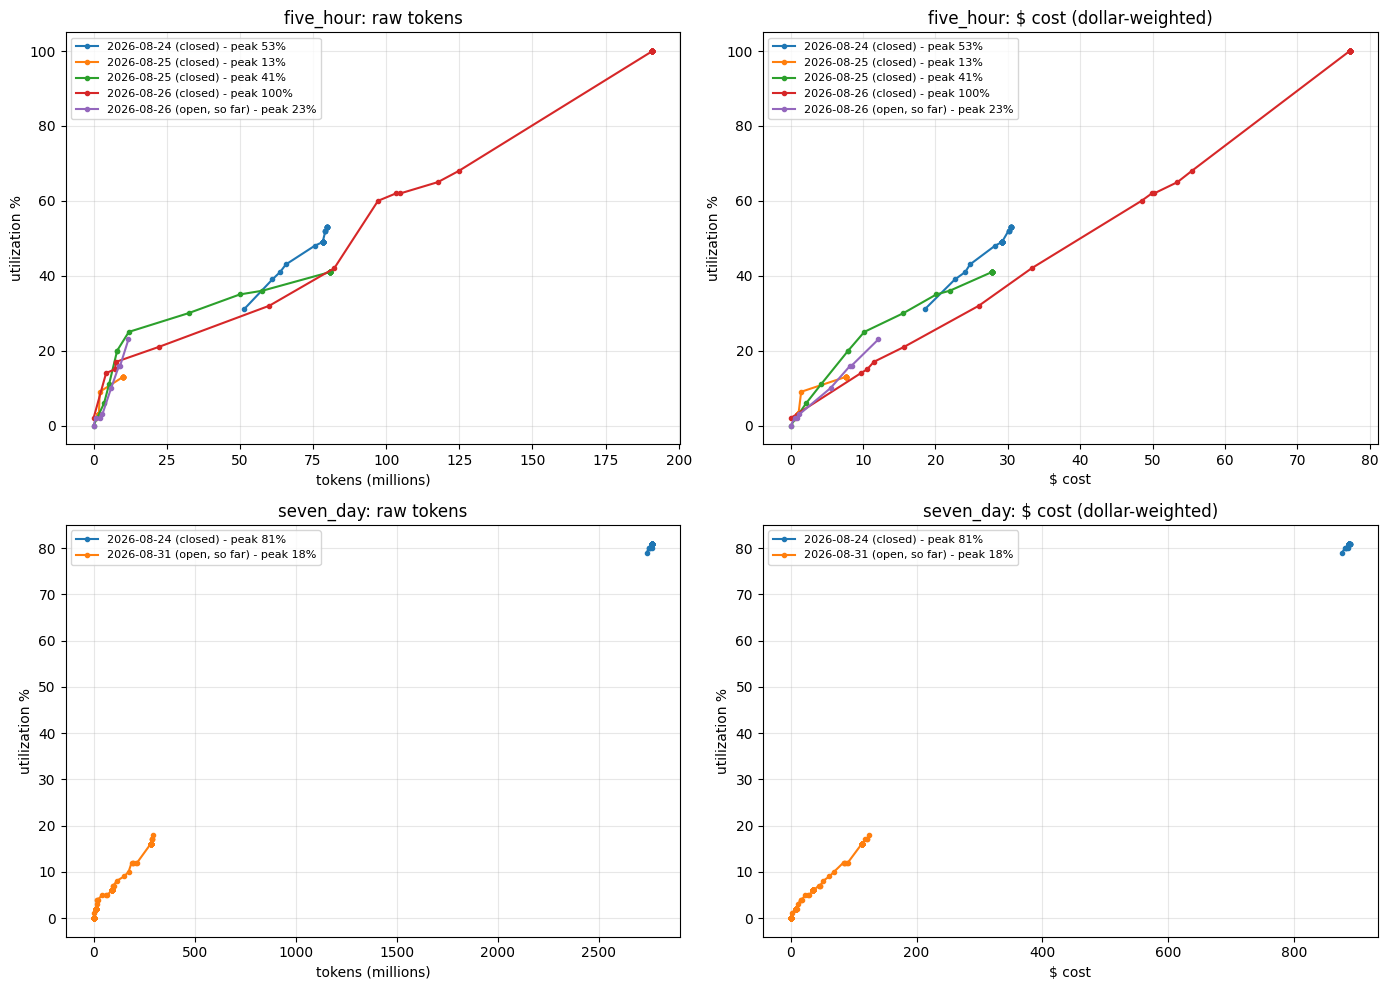

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_windows(axes[0][0], fh_windows, "raw_tokens", "five_hour_pct",
             "five_hour: raw tokens", "tokens (millions)", scale=1e6)
plot_windows(axes[0][1], fh_windows, "dollar_cost", "five_hour_pct",
             "five_hour: $ cost (dollar-weighted)", "$ cost")
plot_windows(axes[1][0], sd_windows, "raw_tokens", "seven_day_pct",
             "seven_day: raw tokens", "tokens (millions)", scale=1e6)
plot_windows(axes[1][1], sd_windows, "dollar_cost", "seven_day_pct",
             "seven_day: $ cost (dollar-weighted)", "$ cost")

fig.tight_layout()
plt.show()

**What to look for**: does each line look straight (linear within a
window)? Do different windows' lines have roughly the same slope (a
stable "budget" - $ or tokens per percentage point) - and is that
slope more consistent in the raw-tokens view or the $-cost view? A
consistent slope across windows in one view but not the other is
evidence for (or against) that view's weighting hypothesis.

## Swapped-axes view

Same data, `SWAP_AXES = True` - X = utilization %, Y = tokens/cost used.
Toggle the `SWAP_AXES` variable near the top of the notebook and re-run
if you'd rather have every plot in this orientation by default.

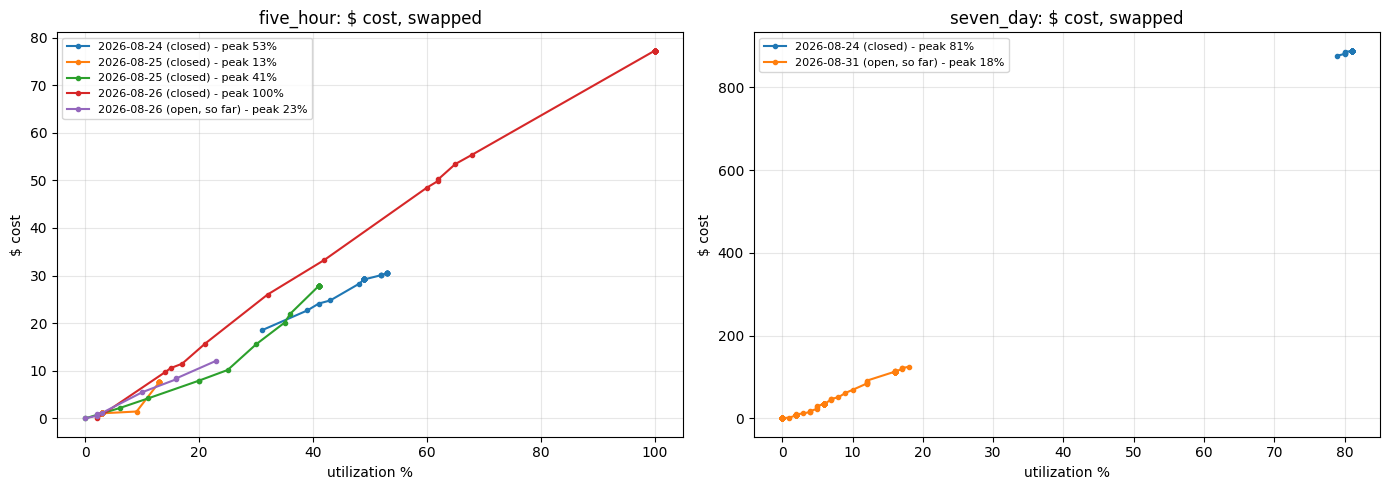

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_windows(axes[0], fh_windows, "dollar_cost", "five_hour_pct",
             "five_hour: $ cost, swapped", "$ cost", swap=True)
plot_windows(axes[1], sd_windows, "dollar_cost", "seven_day_pct",
             "seven_day: $ cost, swapped", "$ cost", swap=True)
fig.tight_layout()
plt.show()